In [47]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import cmocean.cm as cmo

import numpy as np
from scipy.special import logsumexp
import torch
import torch.optim
from flonacomldft.utils.data_utils import (
    load_from_pickle, load_zmat_csv, load_csv_file, get_path, 
)
from flonacomldft.internal_coordinates import get_mix_data
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.visualize import plotting_fes_db

from flonacomldft.internal_coordinates import Coordinates_mapping, Angles_mapping
from flonacomldft.collective_variables import get_CVs, compute_C, compute_R
# from flonacomldft.models import Uncentered_MLP
# from flonacomldft.mixture import Mixture, get_models
# from flonacomldft.dft_utils import Coordinates_mapping
# from flonacomldft.internal_coordinates import Angles_mapping

In [2]:
data_path = get_path()
data_path

'/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/database/'

In [8]:
data_is1 = load_zmat_csv("is1")
data_is2 = load_zmat_csv("is2")

xis, uis, cis = get_mix_data(data_is1, data_is2)

# Pretrain mlps and flows

# loading pretrain mlps models
mlp_is1 = load_from_pickle(get_path() + "mlp_is1")
mlp_is2 = load_from_pickle(get_path() + "mlp_is2")

# loading pretrain flows models
dic_from_training_nf_is1 = load_from_pickle(get_path() + "training_is1")
nf_is1 = dic_from_training_nf_is1["model"]
dic_from_training_nf_is2 = load_from_pickle(get_path() + "training_is2")
nf_is2 = dic_from_training_nf_is2["model"]

In [4]:
xis.shape, uis.shape, cis.shape

(torch.Size([10002, 12]), torch.Size([10002]), torch.Size([10002]))

In [ ]:
T = 300
kb = 8.617333262e-5
beta = 1 / (kb * T)

<AxesSubplot:xlabel='Coordination Number', ylabel='Radius of Gyration [$\\mathrm{\\AA}$]'>

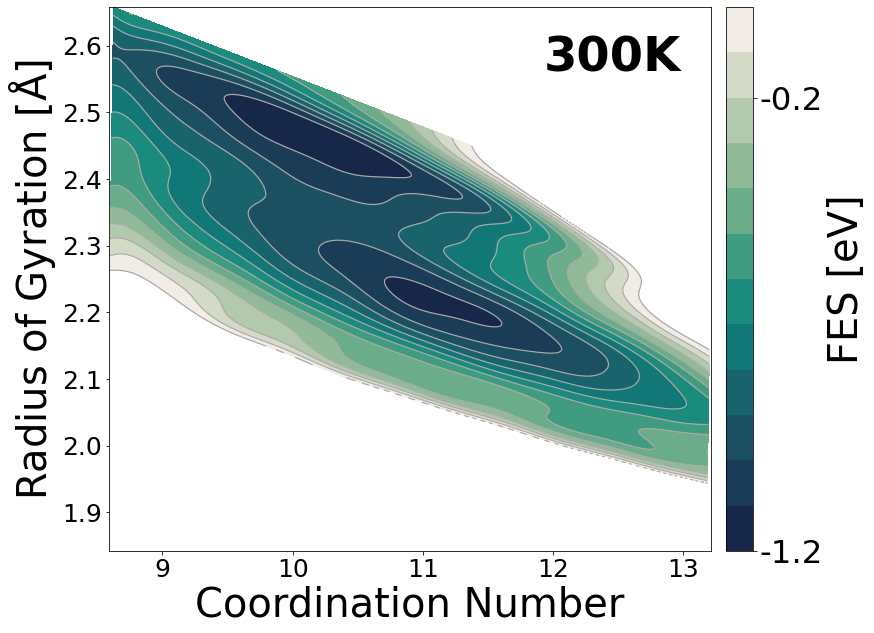

In [6]:
plotting_fes_db()

# Trying with importance sampling

In [67]:
n_samples = 1000

xs = nf_is1.sample(n_samples)
raise Warning("Check the angle mapping and computations of the mean and covariance")
Angles_mapping().mapping(xs)
log_weights = (- beta * mlp_is1.predict(xs).squeeze() + nf_is1.nll(xs)).detach().numpy()
log_normed_weights = log_weights - logsumexp(log_weights)
normed_weights = np.exp(log_normed_weights)
cvs = np.array(get_CVs(xs)).T

In [70]:
# equals one if all participate - equal 1/n_samples if one only participate
normed_part_ratio = normed_weights.sum() / (normed_weights ** 2).sum() / n_samples 
normed_part_ratio

0.001

In [68]:
out = np.histogram2d(cvs[:,0], cvs[:,1], bins=20, weights=normed_weights)

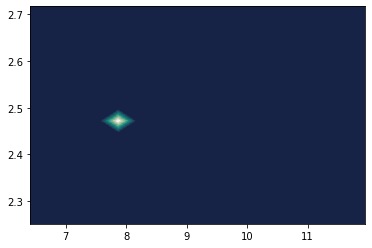

In [69]:
hist, xedges, yedges = out
xpos = 0.5 * (xedges[:-1]+xedges[1:])
ypos = 0.5 * (yedges[:-1]+yedges[1:])
plt.contourf(xpos, ypos, hist, 20, cmap=cmo.tempo_r)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [62]:
n_samples = 1000

xs = nf_is2.sample(n_samples)
raise Warning("Check the angle mapping and computations of the mean and covariance")
Angles_mapping().mapping(xs)
log_weights = (- beta * mlp_is2.predict(xs).squeeze() + nf_is2.nll(xs)).detach().numpy()
log_normed_weights = log_weights - logsumexp(log_weights)
normed_weights = np.exp(log_normed_weights)
cvs = np.array(get_CVs(xs)).T

In [63]:
# equals one if all participate - equal 1/n_samples if one only participate
normed_part_ratio = normed_weights.sum() / (normed_weights ** 2).sum() / n_samples 
normed_part_ratio

0.001

(array([ 38., 236., 324., 229., 101.,  53.,  16.,   1.,   1.,   1.]),
 array([-6573.8003, -5916.4204, -5259.04  , -4601.66  , -3944.2803,
        -3286.9001, -2629.52  , -1972.1401, -1314.76  ,  -657.38  ,
            0.    ], dtype=float32),
 <BarContainer object of 10 artists>)

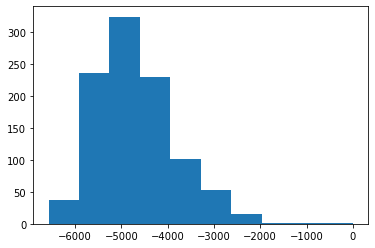

In [64]:
plt.hist(log_normed_weights)

(array([999.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float32),
 <BarContainer object of 10 artists>)

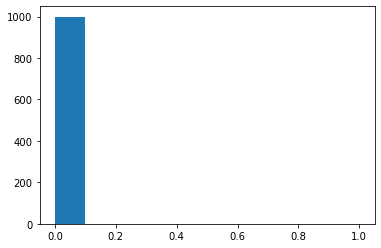

In [65]:
plt.hist(normed_weights)

tensor([ True,  True,  True,  True,  True, False, False, False, False, False,
        False, False])